In [ ]:
!pip install yfinance pandas numpy scikit-learn matplotlib --upgrade

In [3]:
#Predicting Apple's Next-Day Closing Stock Price

#Goal: Use Apple's (AAPL) historical daily stock data — Open, High, Low, 
#Close, Volume — to predict the next day's closing price using a Linear 
#Regression model.

#Why this matters: Investors and analysts often want a quick estimate of 
#where a stock price is headed. This project tests whether simple daily 
#trading numbers can predict tomorrow's close.

In [6]:
import yfinance as yf            # to fetch stock data from Yahoo Finance
import pandas as pd              # to handle tabular data
import numpy as np               # for numerical operations
import matplotlib.pyplot as plt  # for plotting graphs

In [7]:
# Fetch 6 months of Apple (AAPL) daily stock data as a quick test
df = yf.download("AAPL", period="6mo")

# Show the first few rows and the dimensions (rows, columns)
print(df.head())
print(df.shape)

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2025-12-17  271.335876  275.647872  271.136266  274.500011   50138700
2025-12-18  271.685242  273.122574  266.454969  273.102591   51630700
2025-12-19  273.162506  274.090774  269.399478  271.645305  144632000
2025-12-22  270.467499  273.372106  270.008360  272.353978   36571800
2025-12-23  271.854919  271.994674  269.060124  270.337749   29642000
(124, 5)


In [8]:
# Fetch 5 years of Apple (AAPL) daily data for training
df = yf.download("AAPL", period="5y")

# Flatten the column headers (yfinance returns a multi-level header by default)
df.columns = df.columns.get_level_values(0)

# Check for missing values
print(df.isnull().sum())

# Preview the data
print(df.head())
print(df.shape)

[*********************100%***********************]  1 of 1 completed

Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64
Price            Close        High         Low        Open     Volume
Date                                                                 
2021-06-17  128.462524  129.203345  126.376556  126.522778   96721700
2021-06-18  127.166145  128.189623  126.951699  127.409833  108953300
2021-06-21  128.959702  129.066925  125.947721  127.010197   79663300
2021-06-22  130.597260  130.694741  128.296844  128.793977   74783600
2021-06-23  130.324310  130.928667  129.866176  130.392550   60214200
(1255, 5)


In [11]:
# Data Exploration

#Before building any model, let's look at how Apple's closing price has moved over the last 5 years, and check some basic statistics.

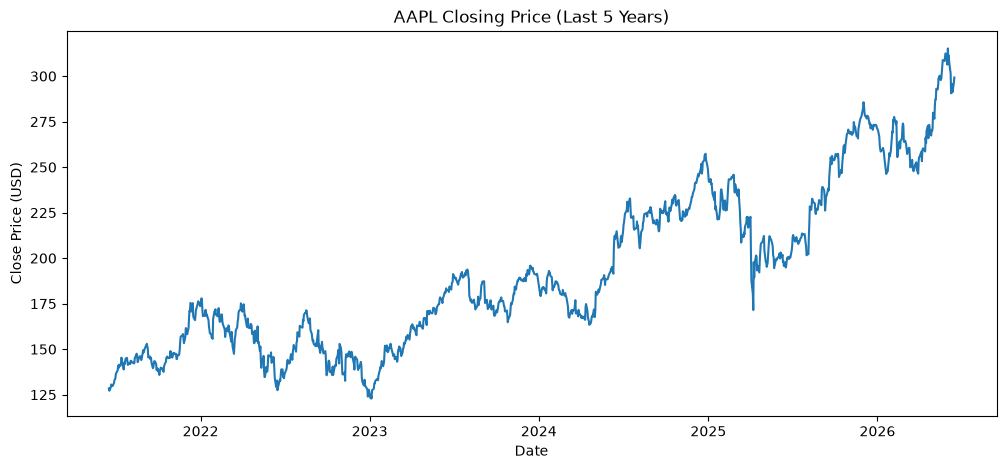

Price        Close         High          Low         Open        Volume
count  1255.000000  1255.000000  1255.000000  1255.000000  1.255000e+03
mean    192.523664   194.425038   190.445516   192.326250  6.523922e+07
std      44.343286    44.695851    44.001988    44.351114  2.818695e+07
min     122.933548   125.637653   122.097723   123.907041  1.791060e+07
25%     155.214073   157.592313   152.941122   155.572319  4.598920e+07
50%     181.477951   183.123169   179.549020   181.416678  5.745070e+07
75%     225.860191   227.876755   223.736691   225.824179  7.738550e+07
max     315.200012   317.399994   309.649994   314.179993  3.186799e+08


In [12]:
# Plot Apple's closing price over time
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Close'])
plt.title("AAPL Closing Price (Last 5 Years)")
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")
plt.show()

# Basic statistics for all columns
print(df.describe())

In [13]:
# Preprocessing: Creating the Target Variable
#We want to predict tomorrow's closing price using today's data. So we create a new column, `Next_Close`, which is just the `Close` price shifted one day backward — meaning each row will show today's Open/High/Low/Volume alongside *tomorrow's* Close price.

In [14]:
# Shift the Close column up by 1 row to create "tomorrow's close" as a new column
df['Next_Close'] = df['Close'].shift(-1)

# The very last row won't have a "tomorrow" to look at, so it becomes NaN — drop it
df = df.dropna()

# Confirm it worked
print(df[['Close', 'Next_Close']].head())
print(df.shape)

Price            Close  Next_Close
Date                              
2021-06-17  128.462524  127.166145
2021-06-18  127.166145  128.959702
2021-06-21  128.959702  130.597260
2021-06-22  130.597260  130.324310
2021-06-23  130.324310  130.041626
(1254, 6)


In [15]:
# Train/Test Split
#We split the data into a training set (older data) and a test set (more recent data). We do NOT shuffle the data randomly, because this is time series — the order matters, and shuffling would let the model "see the future" during training, which isn't realistic.

In [16]:
from sklearn.model_selection import train_test_split

# Features: what the model uses to make predictions
X = df[['Open', 'High', 'Low', 'Volume']]

# Target: what the model is trying to predict
y = df['Next_Close']

# Split chronologically: first 80% for training, last 20% for testing
# shuffle=False keeps the time order intact
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (1003, 4)
Test size: (251, 4)


In [17]:
# Model Training
#We train a Linear Regression model on the training data. It will learn the relationship between today's Open/High/Low/Volume and tomorrow's closing price.

In [18]:
from sklearn.linear_model import LinearRegression

# Create the model
model = LinearRegression()

# Train it on the training data
model.fit(X_train, y_train)

print("Model trained successfully")
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Model trained successfully
Coefficients: [ 3.30846842e-01  3.36050855e-01  3.26076861e-01 -3.53648272e-09]
Intercept: 1.6763377313119179


In [19]:
# Model Evaluation
# We use the trained model to predict closing prices on the test set (data it hasn't seen), then measure how close those predictions are to the actual values using MAE, RMSE, and R².

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predict on the test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 3.370933748041671
RMSE: 4.503152356977916
R2 Score: 0.9730664950608219


In [21]:
# R² score on training data (how well it fits data it learned from)
train_accuracy = model.score(X_train, y_train)

# R² score on testing data (how well it generalizes to unseen data)
test_accuracy = model.score(X_test, y_test)

print("Training Accuracy (R²):", train_accuracy)
print("Testing Accuracy (R²):", test_accuracy)

Training Accuracy (R²): 0.9874291861700323
Testing Accuracy (R²): 0.9730664950608219


In [22]:
# Actual vs Predicted Closing Prices
# Plotting the model's predictions against the real closing prices on the test set lets us visually check how well it's tracking actual price movement.

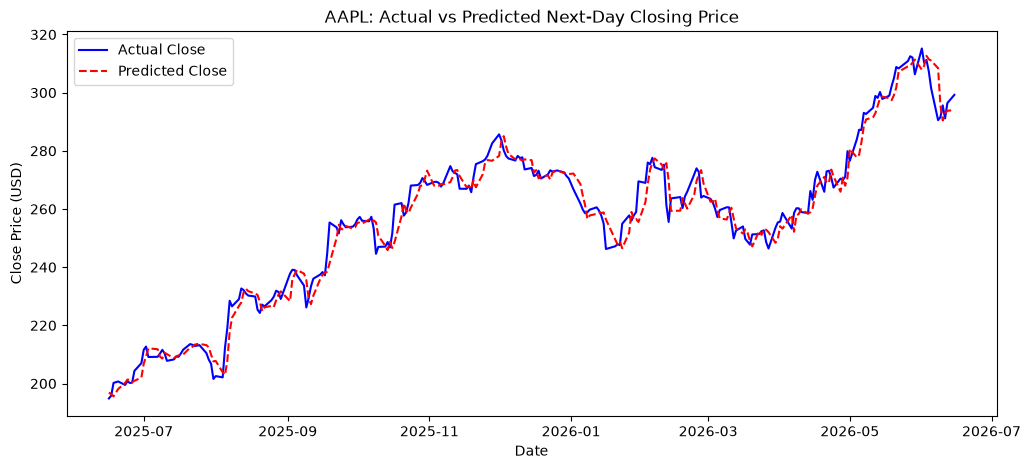

In [23]:
# Plot actual vs predicted closing prices
plt.figure(figsize=(12, 5))
plt.plot(y_test.index, y_test.values, label="Actual Close", color="blue")
plt.plot(y_test.index, y_pred, label="Predicted Close", color="red", linestyle="--")
plt.title("AAPL: Actual vs Predicted Next-Day Closing Price")
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")
plt.legend()
plt.show()

In [ ]:
# Final Insights

#- The Linear Regression model achieved an R² of ~0.97 on test data, meaning it explains about 97% of the variation in next-day closing prices.
#- Training (0.987) and testing (0.973) accuracy were close, indicating the model generalizes well rather than overfitting.
#- Open, High, and Low prices were the strongest predictors, while Volume had almost no effect on the prediction.
#- This high accuracy is expected for short-term price prediction: a  stock's price today is usually very close to its price tomorrow, so the model is mostly learning "tomorrow looks like today" rather than  predicting genuine market shifts.
#- A model like this would NOT be reliable for predicting sudden price jumps caused by news, earnings reports, or other real-world events, since it only learns from historical price patterns.